# Sample Graphs

In [1]:
## Imports
import matplotlib as mpl
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import plotly.graph_objects as go
import rich
from pathlib import Path

import social_networks.utils as ut
import social_networks.visualize as viz
from social_networks.describe import describe_graph

In [2]:
# Run this once
%matplotlib widget

%load_ext autoreload
%autoreload 2

# Custom Node Position

https://networkx.org/documentation/latest/auto_examples/drawing/plot_center_node.html#sphx-glr-auto-examples-drawing-plot-center-node-py

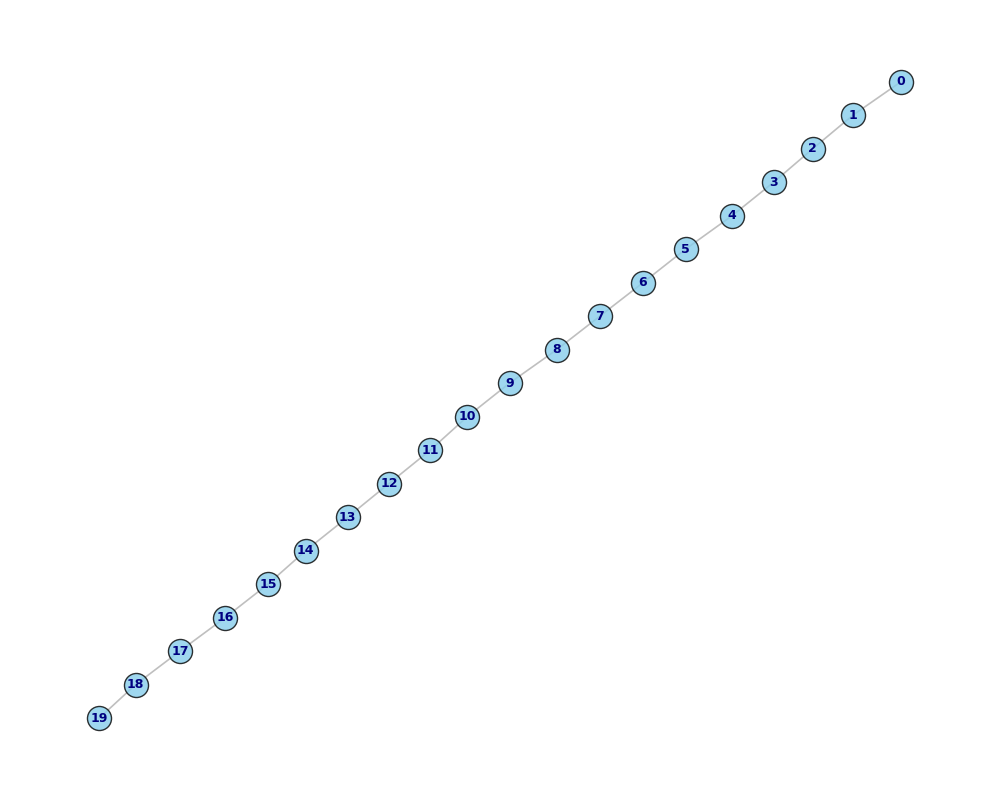

In [3]:
G = nx.path_graph(20)  # An example graph
viz.draw_pretty_hover(G);


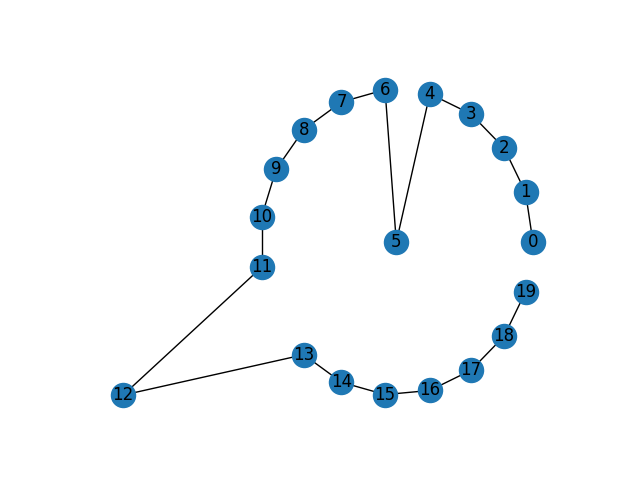

In [4]:
plt.clf()
plt.close('all')
fig, ax = plt.subplots()

center_node = 5  # Pick a node to be in the center
edge_nodes = set(G) - {center_node}

# Ensure nodes around the circle are evenly distributed
pos = nx.circular_layout(G.subgraph(edge_nodes))
pos[center_node] = np.array([0, 0]) # manually specify the node position
pos[12] = np.array([-2, -1])

nx.draw(G, pos, with_labels=True)

# Degree Analysis

https://networkx.org/documentation/latest/auto_examples/drawing/plot_degree.html#sphx-glr-auto-examples-drawing-plot-degree-py

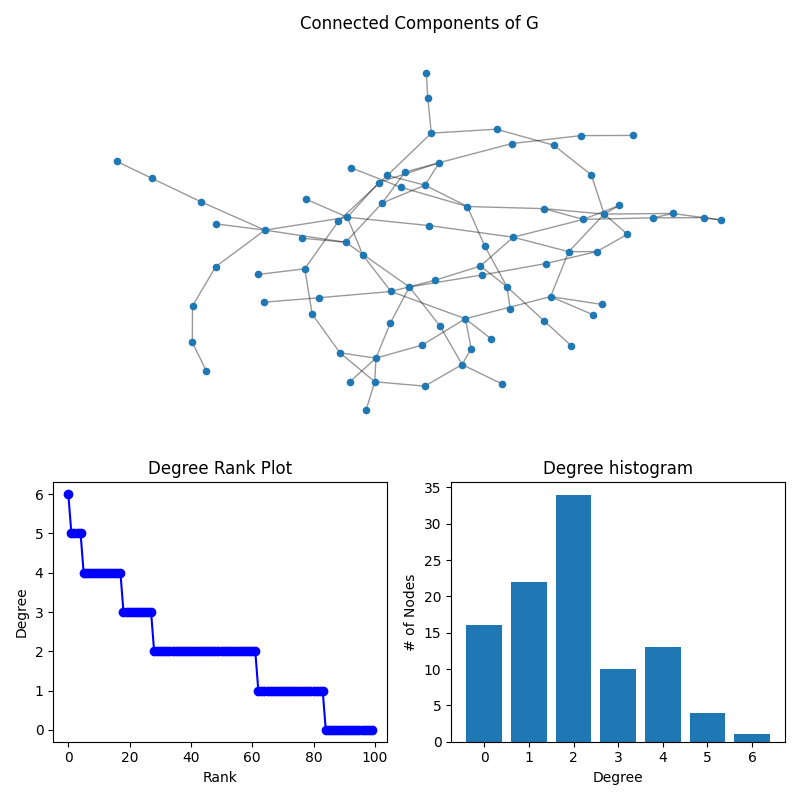

In [5]:
G = nx.gnp_random_graph(100, p=0.02, seed=10374196)

degree_sequence = sorted((d for n, d in G.degree()), reverse=True)
dmax = max(degree_sequence)

# plt.clf()
plt.close("all")
fig = plt.figure("Degree of a random graph", figsize=(8, 8))

# Create a gridspec for adding subplots of different sizes
axgrid = fig.add_gridspec(nrows=5, ncols=4)

ax0 = fig.add_subplot(axgrid[0:3, :])
Gcc = G.subgraph(sorted(nx.connected_components(G), key=len, reverse=True)[0])
pos = nx.spring_layout(Gcc, seed=10396953)
nx.draw_networkx_nodes(Gcc, pos, ax=ax0, node_size=20)
nx.draw_networkx_edges(Gcc, pos, ax=ax0, alpha=0.4)
ax0.set_title("Connected Components of G")
ax0.set_axis_off()

ax1 = fig.add_subplot(axgrid[3:, :2])
ax1.plot(degree_sequence, "b-", marker="o")
ax1.set(title="Degree Rank Plot", ylabel="Degree", xlabel="Rank")

ax2 = fig.add_subplot(axgrid[3:, 2:])
ax2.bar(*np.unique(degree_sequence, return_counts=True))
ax2.set(title="Degree histogram", xlabel="Degree", ylabel="# of Nodes")

fig.tight_layout()
plt.show()

# Directed Graph

https://networkx.org/documentation/latest/auto_examples/drawing/plot_directed.html#sphx-glr-auto-examples-drawing-plot-directed-py

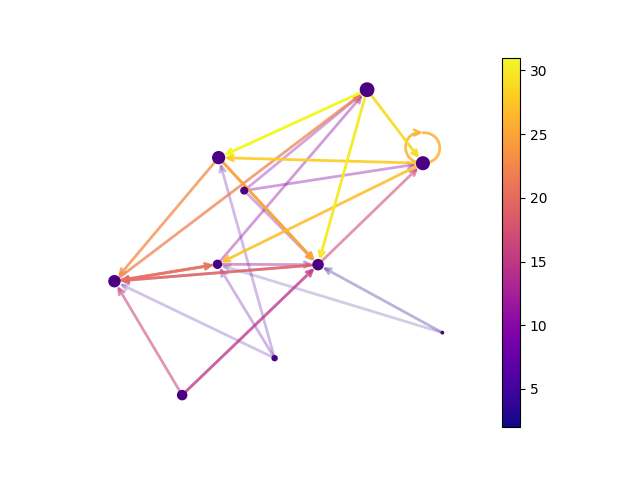

In [6]:
plt.close("all")

seed = 13648  # Seed random number generators for reproducibility
G = nx.random_k_out_graph(10, 3, 0.5, seed=seed)
pos = nx.spring_layout(G, seed=seed)

node_sizes = [3 + 10 * i for i in range(len(G))]
M = G.number_of_edges()
edge_colors = range(2, M + 2)
edge_alphas = [(5 + i) / (M + 4) for i in range(M)]
cmap = plt.cm.plasma

nodes = nx.draw_networkx_nodes(G, pos=pos, node_size=node_sizes, node_color="indigo")
edges = nx.draw_networkx_edges(
    G,
    pos=pos,
    node_size=node_sizes,
    arrowstyle="->",
    arrowsize=10,
    edge_color=edge_colors,
    edge_cmap=cmap,
    width=2,
)

# Set the alpha value for edge edge
for i in range(M):
    edges[i].set_alpha(edge_alphas[i])

pc = mpl.collections.PatchCollection(edges, cmap=cmap)
pc.set_array(edge_colors)

# fig, ax = plt.subplots(figsize=(8,8))
ax = plt.gca()
ax.set_axis_off()
plt.colorbar(pc, ax=ax)
plt.show()

# Random Geometric Graph

https://networkx.org/documentation/latest/auto_examples/drawing/plot_random_geometric_graph.html#sphx-glr-auto-examples-drawing-plot-random-geometric-graph-py

## Examine nodes and attributes

In [7]:
G = nx.random_geometric_graph(n=5, radius=0.125, seed=896803)

# position is stored as node attribute data for random_geometric_graph
pos = nx.get_node_attributes(G, "pos")

In [8]:
pos

{0: [0.5846753145673486, 0.2290076495880834],
 1: [0.7218497561322836, 0.5327399549618553],
 2: [0.8204451725045246, 0.1917614793352539],
 3: [0.2004011822632138, 0.44367399281213826],
 4: [0.6646532104299433, 0.4338917373852025]}

In [9]:
rich.print(G.nodes(data=True))

[(0, {'pos': [0.5846753145673486, 0.2290076495880834]}), (1, {'pos': [0.7218497561322836, 0.5327399549618553]}), 
(2, {'pos': [0.8204451725045246, 0.1917614793352539]}), (3, {'pos': [0.2004011822632138, 0.44367399281213826]}), 
(4, {'pos': [0.6646532104299433, 0.4338917373852025]})]

## Draw random geometric graph

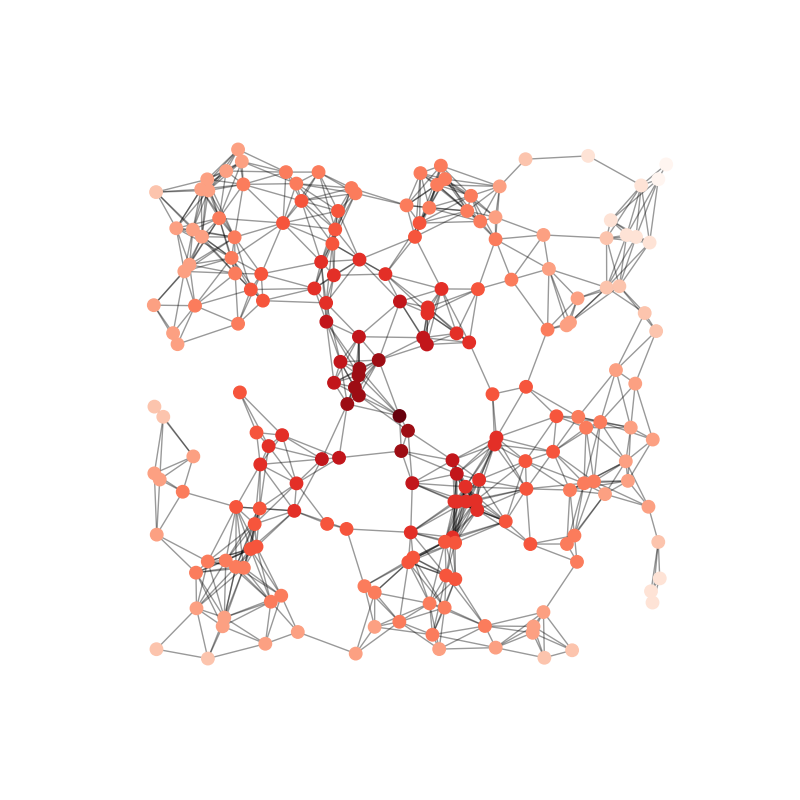

In [10]:
plt.close("all")
G = nx.random_geometric_graph(n=200, radius=0.125, seed=896803)

# position is stored as node attribute data for random_geometric_graph
pos = nx.get_node_attributes(G, "pos")

# find node near center (0.5, 0.5)
dmin = 1
ncenter = 0
for n in pos:
    x, y = pos[n]
    d = (x - 0.5) ** 2 + (y - 0.5) ** 2
    if d < dmin:
        ncenter = n
        dmin = d

# color by path length from node near center
p = nx.single_source_shortest_path_length(G=G, source=ncenter)

plt.figure(figsize=(8, 8))
nx.draw_networkx_edges(G, pos, alpha=0.4)
nx.draw_networkx_nodes(
    G,
    pos=pos,
    nodelist=list(p.keys()),
    node_size=80,
    node_color=list(p.values()),
    cmap=plt.cm.Reds_r,
)
ax.set(
    xlim=(-0.05, 1.05),
    ylim=(-0.05, 1.05),
)
plt.axis("off")
plt.show()

# Four grids

In [11]:
G = nx.grid_2d_graph(4, 4) # 4x4 grid

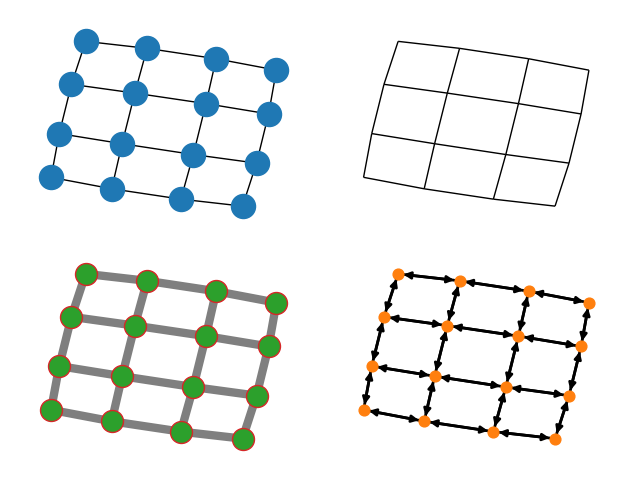

In [12]:
pos = nx.spring_layout(G, iterations=100, seed=39775)

# Create a 2x2 subplot
fig, axes = plt.subplots(2, 2)
ax = axes.flat

nx.draw(G, pos, ax=ax[0], font_size=8)
nx.draw(G, pos, ax=ax[1], node_size=0, with_labels=False)
nx.draw(
    G,
    pos,
    ax=ax[2],
    node_color="tab:green",
    edgecolors="tab:red",  # Node surface color
    edge_color="tab:gray",  # Color of graph edges
    node_size=250,
    with_labels=False,
    width=6,
)
H = G.to_directed()
nx.draw(
    H,
    pos,
    ax=ax[3],
    node_color="tab:orange",
    node_size=60,
    with_labels=False,
    arrowsize=10,
    width=2,
)

# Set margins for the axes so the nodes aren't clipped
for a in ax:
    a.margins(0.10)
fig.tight_layout()
plt.show()

# Built-in datasets

In [13]:
# social-networks directory (git root)
path_root = ut.find_git_root()
path_work = path_root / "notebooks" / "work"
path_course5 = path_work / "resources" / "course5"

In [14]:
fname = path_course5 /"chess_graph.txt"
chess = nx.read_edgelist(fname, data=[('outcome', int), ('timestamp', float)], 
                         create_using=nx.MultiDiGraph())

In [ ]:
viz.draw_pretty_hover(chess)

In [ ]:
fname = path_course5 / "G_edgelist.txt"
G = nx.read_edgelist(fname)
nx.draw_networkx(G)

TypeError: Failed to convert edge data (['4']) to dictionary.

In [ ]:
G.

EdgeView([((0, 0), (1, 0)), ((0, 0), (0, 1)), ((0, 1), (1, 1)), ((0, 1), (0, 2)), ((0, 2), (1, 2)), ((0, 2), (0, 3)), ((0, 3), (1, 3)), ((1, 0), (2, 0)), ((1, 0), (1, 1)), ((1, 1), (2, 1)), ((1, 1), (1, 2)), ((1, 2), (2, 2)), ((1, 2), (1, 3)), ((1, 3), (2, 3)), ((2, 0), (3, 0)), ((2, 0), (2, 1)), ((2, 1), (3, 1)), ((2, 1), (2, 2)), ((2, 2), (3, 2)), ((2, 2), (2, 3)), ((2, 3), (3, 3)), ((3, 0), (3, 1)), ((3, 1), (3, 2)), ((3, 2), (3, 3))])

In [ ]:
G = nx.read_edgelist(path="")